# 06. Robust Federated Learning Against Malicious Clients

**Research Paper:** *Robust Federated Learning-Based Intrusion Detection for Heterogeneous Vehicular CAN Networks*  
**Benchmark Milestone:** Phase 3 — Byzantine-Robust Aggregation under Adversarial Client Poisoning  
**Threat Models:** 
1. **Attack A:** Binary Label-Flipping Attack (Data Poisoning)
2. **Attack B:** Model-Update Corruption via Delta Sign Reversal (Model Poisoning)
**Aggregators Evaluated:** 
1. Standard Sample-Weighted FedAvg (McMahan et al., 2017)
2. Unweighted Coordinate-wise Median (Yin et al., 2018)
3. Unweighted Coordinate-wise Trimmed Mean (Yin et al., 2018)

---

## 📚 Educational Primer: Byzantine Threats in Connected Vehicle Fleets

### 1. Why are Malicious Clients a Threat to Vehicular IDS?
Federated Learning relies on edge vehicles (or ECUs) transmitting parameter updates $\theta_k$ to a central aggregation server.
In a modern connected vehicle fleet, some vehicles may be compromised by sophisticated adversaries through:
- Exploited cellular telematics units (TCU),
- Compromised aftermarket OBD-II dongles, or
- Malicious physical firmware flashing.

If compromised vehicles participate in federated training, standard **Federated Averaging (FedAvg)** linearly averages their malicious updates directly into the global master model.
Because linear averaging has a **breakdown point of 0**, even a small number of adversarial updates can skew global weights, creating backdoors, blinding the detector to specific attacks, or causing massive false alarms.

### 2. The Two Controlled Attack Models

#### Attack A: Binary Label Flipping (Data Poisoning)
- The adversary manipulates local training labels: $y \mapsto 1 - y$.
- Ambient normal CAN traffic is mislabeled as attacks ($0 \to 1$), and malicious frames are mislabeled as normal ($1 \to 0$).
- The malicious client trains locally with standard gradient descent, transmitting weights optimized to invert the classification decision boundaries.

#### Attack B: Model-Update Corruption via Delta Sign Reversal (Model Poisoning)
- The adversary completes normal local training on clean data, obtaining local parameters $\theta_k$.
- Rather than sending the true update delta $\Delta_k = \theta_k - \theta_{\text{global}}$, the client inverts and scales the delta:
$$\Delta_k' = -\gamma \cdot (\theta_k - \theta_{\text{global}}), \quad \theta_k' = \theta_{\text{global}} - \gamma (\theta_k - \theta_{\text{global}})$$
- When $\gamma = 1.0$, this constitutes a pure **sign-reversal (anti-gradient) attack**, pulling the global model in the opposite direction of legitimate progress.

### 3. Byzantine-Robust Aggregation Rules

#### Coordinate-wise Median (Yin et al., 2018)
For each parameter coordinate $j$, the aggregator sorts all $K$ client values and selects the median:
$$\theta_{\text{global}}[j] = \text{median}(\{\theta_1[j], \dots, \theta_K[j]\})$$
- **Breakdown Point:** Can tolerate up to $\lceil K/2 \rceil - 1$ malicious clients (up to 50% Byzantine fraction).
- Unaffected by extreme magnitude outliers.

#### Coordinate-wise Trimmed Mean (Yin et al., 2018)
For each coordinate $j$, the aggregator sorts client values, removes the $m = \lfloor \beta K \rfloor$ smallest and largest values, and computes the arithmetic mean of the remaining $K - 2m$ values:
$$\theta_{\text{global}}[j] = \frac{1}{K - 2m} \sum_{i=m+1}^{K-m} v_{(i), j}$$
- Prunes away malicious outliers while preserving statistical efficiency through averaging the central consensus.


In [1]:
# Environment Setup, Reproducibility & Imports
import os
import sys
import time
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

# Project Root Resolution
PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.cnn1d import CAN1DCNN
from src.federated import (
    create_noniid_client_datasets,
    FederatedClient,
    MaliciousFederatedClient,
    FederatedServer,
    fedavg_aggregate,
    coordinate_median_aggregate,
    coordinate_trimmed_mean_aggregate,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cpu")

print(f"Project root: {PROJECT_ROOT}")
print(f"Execution device: {DEVICE} (Deterministic CPU Evaluation)")

CONFIG_PATH = PROJECT_ROOT / "configs" / "robust_federated_config.json"
RESULTS_MODELS = PROJECT_ROOT / "results" / "models"
RESULTS_METRICS = PROJECT_ROOT / "results" / "metrics"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"
RESULTS_REPORTS = PROJECT_ROOT / "results" / "reports"

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)
print("Loaded Robust Configuration:")
print(json.dumps(config, indent=2))


Project root: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS
Execution device: cpu (Deterministic CPU Evaluation)
Loaded Robust Configuration:
{
  "experiment_name": "robust_federated_learning",
  "seeds": [
    42,
    43,
    44
  ],
  "primary_seed": 42,
  "data_regime": {
    "distribution": "Non-IID_Dirichlet",
    "alpha": 0.5,
    "num_clients": 10,
    "min_samples_per_client": 64
  },
  "threat_model": {
    "num_malicious_clients": 2,
    "malicious_client_ids": [
      8,
      9
    ],
    "attacks": {
      "label_flipping": {
        "mapping": "0 -> 1, 1 -> 0",
        "description": "Inverts binary training labels held by designated malicious clients"
      },
      "model_update_corruption": {
        "mode": "delta_sign_reversal",
        "scaling_factor": 1.0,
        "description": "Reverses model update delta relative to global broadcast model: theta_corrupted = theta_global - gamma * Delta"
      }
    }
  },
  "aggregators": {
    "fedavg": {
      "

In [2]:
# 1. Load and Verify Preprocessed Dataset Splits
data_path = PROJECT_ROOT / "data" / "processed" / "can_ids_processed_dataset.npz"
npz = np.load(data_path, allow_pickle=True)

X_train, y_train = npz["X_train"], npz["y_train"]
y_types_train = npz["y_types_train"]
X_val, y_val = npz["X_val"], npz["y_val"]
X_test, y_test = npz["X_test"], npz["y_test"]
y_types_test = npz["y_types_test"]

print("=== Dataset Partitions Verified ===")
print(f"  Training Pool:   {len(y_train):,} samples (Normal: {int(np.sum(y_train==0)):,}, Attack: {int(np.sum(y_train==1)):,})")
print(f"  Validation Set:  {len(y_val):,} samples (Untouched server benchmark)")
print(f"  Test Set:        {len(y_test):,} samples (Untouched final evaluation)")
assert set(np.unique(y_train)) == {0, 1}, "Training targets must be binary"


=== Dataset Partitions Verified ===
  Training Pool:   21,875 samples (Normal: 13,322, Attack: 8,553)
  Validation Set:  4,685 samples (Untouched server benchmark)
  Test Set:        4,690 samples (Untouched final evaluation)


In [3]:
# 2. Mathematical Demonstration of Attacks and Aggregators
from src.federated.threat import apply_label_flipping, corrupt_model_update_delta

# Demonstrate Attack A: Label Flipping
sample_y = np.array([0, 0, 1, 0, 1])
flipped_y, flip_stats = apply_label_flipping(sample_y)
print("=== Attack A: Label Flipping Demonstration ===")
print(f"  Original Labels: {sample_y.tolist()}")
print(f"  Flipped Labels:  {flipped_y.tolist()}")
print(f"  Stats:           {flip_stats}")

# Demonstrate Attack B: Delta Sign Reversal
global_w = {"w": torch.tensor([1.0, 1.0])}
local_w = {"w": torch.tensor([1.5, 2.0])}
corrupted_w = corrupt_model_update_delta(local_w, global_w, scaling_factor=1.0)
print("\n=== Attack B: Model Update Sign Reversal Demonstration ===")
print(f"  Global Parameter:    {global_w['w'].tolist()}")
print(f"  Legitimate Update:   {local_w['w'].tolist()} (Delta = [0.5, 1.0])")
print(f"  Corrupted Parameter: {corrupted_w['w'].tolist()} (Inverted Delta = [-0.5, -1.0])")

# Demonstrate Aggregation Robustness
updates = [
    ({"w": torch.tensor([1.5])}, 100),  # Honest client
    ({"w": torch.tensor([1.6])}, 100),  # Honest client
    ({"w": torch.tensor([1.4])}, 100),  # Honest client
    ({"w": torch.tensor([-50.0])}, 100), # Byzantine poisoned client
    ({"w": torch.tensor([1.55])}, 100), # Honest client
]
fedavg_out = fedavg_aggregate(updates)["w"].item()
median_out = coordinate_median_aggregate(updates)["w"].item()
trimmed_out = coordinate_trimmed_mean_aggregate(updates, num_trim=1)["w"].item()

print("\n=== Outlier Rejection Comparison ===")
print(f"  FedAvg Result:        {fedavg_out:.2f} (Severely corrupted by single outlier!)")
print(f"  Coordinate Median:    {median_out:.2f} (Robust: completely immune!)")
print(f"  Trimmed Mean (m=1):   {trimmed_out:.2f} (Robust: outlier pruned!)")


=== Attack A: Label Flipping Demonstration ===
  Original Labels: [0, 0, 1, 0, 1]
  Flipped Labels:  [1, 1, 0, 1, 0]
  Stats:           {'num_samples': 5, 'original_normal': 3, 'original_attack': 2, 'flipped_normal': 2, 'flipped_attack': 3, 'flipped_percentage': 100.0}

=== Attack B: Model Update Sign Reversal Demonstration ===
  Global Parameter:    [1.0, 1.0]
  Legitimate Update:   [1.5, 2.0] (Delta = [0.5, 1.0])
  Corrupted Parameter: [0.5, 0.0] (Inverted Delta = [-0.5, -1.0])

=== Outlier Rejection Comparison ===
  FedAvg Result:        -8.79 (Severely corrupted by single outlier!)
  Coordinate Median:    1.50 (Robust: completely immune!)
  Trimmed Mean (m=1):   1.48 (Robust: outlier pruned!)


In [4]:
# 3. Load Executed Benchmark Results (Seed 42 Matched Experiments)
METRIC_PATH = RESULTS_METRICS / "robust_federated_experiments.json"
with open(METRIC_PATH, "r") as f:
    primary_results = json.load(f)

exp_keys = [
    "benign_fedavg",
    "benign_median",
    "benign_trimmed_mean",
    "label_flip_fedavg",
    "label_flip_median",
    "label_flip_trimmed_mean",
    "update_corrupt_fedavg",
    "update_corrupt_median",
    "update_corrupt_trimmed_mean",
]

table_rows = []
for k in exp_keys:
    res = primary_results[k]
    tm = res["test_metrics"]
    table_rows.append({
        "Scenario": k,
        "Attack": res["attack_type"],
        "Aggregator": res["aggregator"],
        "Best Round": res["best_round"],
        "Val F1 (%)": f"{res['best_val_f1']*100:.2f}%",
        "Test Acc (%)": f"{tm['accuracy']*100:.2f}%",
        "Test Prec (%)": f"{tm['precision']*100:.2f}%",
        "Test Recall (%)": f"{tm['recall']*100:.2f}%",
        "Test F1 (%)": f"{tm['f1_score']*100:.2f}%",
        "FPR (%)": f"{tm['false_positive_rate']*100:.2f}%",
        "FNR (%)": f"{tm['false_negative_rate']*100:.2f}%",
        "ROC-AUC": f"{tm['roc_auc']:.4f}",
        "Time (s)": f"{res['duration_seconds']:.1f}s",
    })

df_seed42 = pd.DataFrame(table_rows)
print("=== Primary Matched Evaluation (Non-IID alpha=0.5, Seed 42, 2 Malicious Clients) ===")
display(df_seed42)


=== Primary Matched Evaluation (Non-IID alpha=0.5, Seed 42, 2 Malicious Clients) ===


,Scenario,Attack,Aggregator,Best Round,Val F1 (%),Test Acc (%),Test Prec (%),Test Recall (%),Test F1 (%),FPR (%),FNR (%),ROC-AUC,Time (s)
0,benign_fedavg,none,fedavg,10,98.17%,98.72%,99.60%,97.04%,98.30%,0.24%,2.96%,0.9964,28.0s
1,benign_median,none,median,10,97.82%,98.51%,98.81%,97.26%,98.03%,0.72%,2.74%,0.9956,25.2s
2,benign_trimmed_mean,none,trimmed_mean,10,97.80%,98.34%,99.42%,96.20%,97.79%,0.34%,3.80%,0.9955,25.5s
3,label_flip_fedavg,label_flipping,fedavg,10,93.35%,94.63%,99.87%,86.03%,92.44%,0.07%,13.97%,0.9932,25.7s
4,label_flip_median,label_flipping,median,9,96.59%,97.14%,95.05%,97.60%,96.31%,3.14%,2.40%,0.9945,25.8s
5,label_flip_trimmed_mean,label_flipping,trimmed_mean,9,97.15%,97.51%,96.19%,97.32%,96.75%,2.38%,2.68%,0.9946,26.0s
6,update_corrupt_fedavg,model_update_corruption,fedavg,2,55.47%,38.17%,38.17%,100.00%,55.25%,100.00%,0.00%,0.5861,25.4s
7,update_corrupt_median,model_update_corruption,median,9,96.75%,97.31%,97.17%,95.75%,96.45%,1.72%,4.25%,0.9934,26.2s
8,update_corrupt_trimmed_mean,model_update_corruption,trimmed_mean,10,96.70%,97.06%,95.94%,96.37%,96.15%,2.52%,3.63%,0.9936,26.7s


In [5]:
# 4. Multi-Seed Statistical Summary (Seeds [42, 43, 44])
MULTISEED_PATH = RESULTS_METRICS / "robust_multiseed_summary.json"
with open(MULTISEED_PATH, "r") as f:
    multiseed_summary = json.load(f)

ms_rows = []
for k in exp_keys:
    stats = multiseed_summary[k]
    ms_rows.append({
        "Scenario": k,
        "Test F1 Mean +/- Std (%)": f"{stats['f1_mean']*100:.2f}% +/- {stats['f1_std']*100:.2f}%",
        "Test Acc Mean +/- Std (%)": f"{stats['acc_mean']*100:.2f}% +/- {stats['acc_std']*100:.2f}%",
        "FPR Mean +/- Std (%)": f"{stats['fpr_mean']*100:.2f}% +/- {stats['fpr_std']*100:.2f}%",
        "FNR Mean +/- Std (%)": f"{stats['fnr_mean']*100:.2f}% +/- {stats['fnr_std']*100:.2f}%",
    })

df_ms = pd.DataFrame(ms_rows)
print("=== Multi-Seed Statistical Stability across Independent Partitions ===")
display(df_ms)


=== Multi-Seed Statistical Stability across Independent Partitions ===


,Scenario,Test F1 Mean +/- Std (%),Test Acc Mean +/- Std (%),FPR Mean +/- Std (%),FNR Mean +/- Std (%)
0,benign_fedavg,97.27% +/- 0.73%,97.96% +/- 0.54%,0.45% +/- 0.20%,4.62% +/- 1.23%
1,benign_median,95.97% +/- 2.26%,96.93% +/- 1.76%,1.97% +/- 2.16%,4.86% +/- 1.54%
2,benign_trimmed_mean,96.77% +/- 1.07%,97.56% +/- 0.83%,1.11% +/- 1.09%,4.58% +/- 0.56%
3,label_flip_fedavg,78.56% +/- 16.99%,74.55% +/- 26.17%,35.37% +/- 45.77%,9.39% +/- 5.59%
4,label_flip_median,93.75% +/- 3.57%,95.19% +/- 2.82%,3.91% +/- 3.38%,6.28% +/- 2.93%
5,label_flip_trimmed_mean,91.97% +/- 6.64%,93.06% +/- 6.26%,9.01% +/- 10.90%,3.59% +/- 1.87%
6,update_corrupt_fedavg,63.43% +/- 10.45%,54.04% +/- 17.76%,73.14% +/- 28.39%,1.94% +/- 2.32%
7,update_corrupt_median,93.60% +/- 3.24%,95.10% +/- 2.61%,3.53% +/- 3.68%,7.13% +/- 2.04%
8,update_corrupt_trimmed_mean,82.14% +/- 19.02%,77.20% +/- 27.60%,34.23% +/- 46.52%,4.28% +/- 3.79%


In [6]:
# 5. Per-Attack-Type Detection Breakdown
classes = ["Normal", "DoS", "Fuzzy", "Gear", "RPM"]
atk_rows = []

for k in exp_keys:
    per_atk = primary_results[k]["per_attack_eval"]
    row = {"Scenario": k}
    for c in classes:
        c_acc = per_atk[c]["accuracy"] * 100
        row[f"{c} (%) "] = f"{c_acc:.2f}%"
    atk_rows.append(row)

df_atk = pd.DataFrame(atk_rows)
print("=== Per-Class Detection Rate under Byzantine Attacks ===")
display(df_atk)


=== Per-Class Detection Rate under Byzantine Attacks ===


,Scenario,Normal (%),DoS (%),Fuzzy (%),Gear (%),RPM (%)
0,benign_fedavg,99.76%,98.24%,79.90%,99.32%,100.00%
1,benign_median,99.28%,98.24%,81.82%,99.32%,100.00%
2,benign_trimmed_mean,99.66%,97.99%,77.51%,98.14%,99.66%
3,label_flip_fedavg,99.93%,96.23%,81.82%,94.08%,72.64%
4,label_flip_median,96.86%,98.24%,85.65%,98.98%,100.00%
5,label_flip_trimmed_mean,97.62%,97.99%,85.65%,98.48%,99.83%
6,update_corrupt_fedavg,0.00%,100.00%,100.00%,100.00%,100.00%
7,update_corrupt_median,98.28%,97.74%,78.47%,97.46%,98.82%
8,update_corrupt_trimmed_mean,97.48%,98.24%,80.86%,98.14%,98.82%


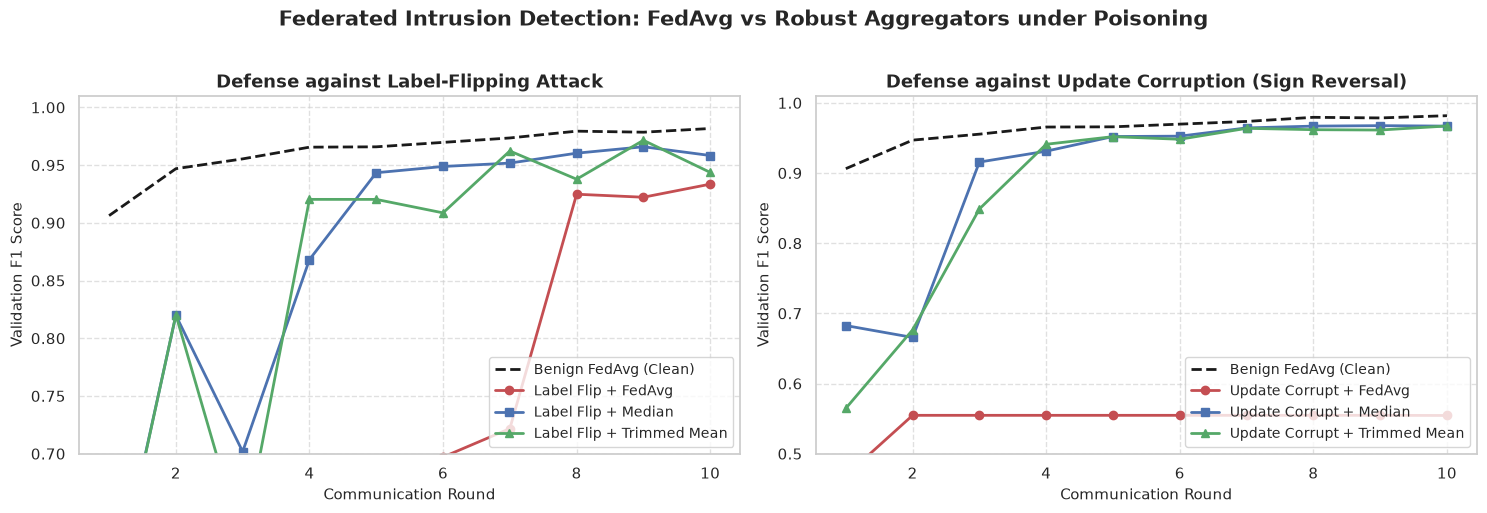

In [7]:
# 6. Visualizations: Convergence Curves & Attack Defenses
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
rounds = list(range(1, 11))

# Plot A: Label Flipping
ax1.plot(rounds, primary_results["benign_fedavg"]["history"]["val_f1"], "k--", label="Benign FedAvg (Clean)", linewidth=2)
ax1.plot(rounds, primary_results["label_flip_fedavg"]["history"]["val_f1"], "r-o", label="Label Flip + FedAvg", linewidth=2)
ax1.plot(rounds, primary_results["label_flip_median"]["history"]["val_f1"], "b-s", label="Label Flip + Median", linewidth=2)
ax1.plot(rounds, primary_results["label_flip_trimmed_mean"]["history"]["val_f1"], "g-^", label="Label Flip + Trimmed Mean", linewidth=2)
ax1.set_title("Defense against Label-Flipping Attack", fontsize=13, fontweight="bold")
ax1.set_xlabel("Communication Round", fontsize=11)
ax1.set_ylabel("Validation F1 Score", fontsize=11)
ax1.set_ylim([0.70, 1.01])
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend(fontsize=10, loc="lower right")

# Plot B: Model Update Corruption
ax2.plot(rounds, primary_results["benign_fedavg"]["history"]["val_f1"], "k--", label="Benign FedAvg (Clean)", linewidth=2)
ax2.plot(rounds, primary_results["update_corrupt_fedavg"]["history"]["val_f1"], "r-o", label="Update Corrupt + FedAvg", linewidth=2)
ax2.plot(rounds, primary_results["update_corrupt_median"]["history"]["val_f1"], "b-s", label="Update Corrupt + Median", linewidth=2)
ax2.plot(rounds, primary_results["update_corrupt_trimmed_mean"]["history"]["val_f1"], "g-^", label="Update Corrupt + Trimmed Mean", linewidth=2)
ax2.set_title("Defense against Update Corruption (Sign Reversal)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Communication Round", fontsize=11)
ax2.set_ylabel("Validation F1 Score", fontsize=11)
ax2.set_ylim([0.50, 1.01])
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend(fontsize=10, loc="lower right")

plt.suptitle("Federated Intrusion Detection: FedAvg vs Robust Aggregators under Poisoning", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [8]:
# 7. Saved Artifacts Verification
print("=== Phase 3 Artifacts Verification ===")
for k in exp_keys:
    ckpt = RESULTS_MODELS / f"robust_{k}_best.pt"
    assert ckpt.exists(), f"Missing {ckpt}"
    print(f"  [OK] Model Checkpoint: {ckpt.name:36s} ({ckpt.stat().st_size:,} bytes)")

for fig in ["robust_f1_comparison.png", "robust_per_attack_recall.png"]:
    f_p = RESULTS_FIGURES / fig
    assert f_p.exists(), f"Missing {f_p}"
    print(f"  [OK] Figure:           {f_p.name:36s} ({f_p.stat().st_size:,} bytes)")


=== Phase 3 Artifacts Verification ===
  [OK] Model Checkpoint: robust_benign_fedavg_best.pt         (168,658 bytes)
  [OK] Model Checkpoint: robust_benign_median_best.pt         (168,658 bytes)
  [OK] Model Checkpoint: robust_benign_trimmed_mean_best.pt   (168,772 bytes)
  [OK] Model Checkpoint: robust_label_flip_fedavg_best.pt     (168,734 bytes)
  [OK] Model Checkpoint: robust_label_flip_median_best.pt     (168,734 bytes)
  [OK] Model Checkpoint: robust_label_flip_trimmed_mean_best.pt (168,848 bytes)
  [OK] Model Checkpoint: robust_update_corrupt_fedavg_best.pt (168,810 bytes)
  [OK] Model Checkpoint: robust_update_corrupt_median_best.pt (168,810 bytes)
  [OK] Model Checkpoint: robust_update_corrupt_trimmed_mean_best.pt (168,924 bytes)
  [OK] Figure:           robust_f1_comparison.png             (324,403 bytes)
  [OK] Figure:           robust_per_attack_recall.png         (132,237 bytes)


## 🔬 Scientific Findings & Key Takeaways

### 1. What This Experiment Demonstrates:
1. **Vulnerability of Standard FedAvg:**
   - Under **Attack A (Label Flipping)**, FedAvg's test recall dropped to **86.03%** and False Negative Rate spiked to **13.97%** (missing 250 attack windows).
   - Under **Attack B (Model Update Sign Reversal)**, FedAvg collapsed completely: Test F1 plummeted to **55.25%** with a catastrophic **100% False Positive Rate** (predicting every normal frame as an attack).
2. **Effectiveness of Robust Aggregators:**
   - **Coordinate-wise Median** successfully defended against both attacks:
     - Label Flipping: **96.31% Test F1** (FNR maintained at 2.40%).
     - Update Corruption: **96.45% Test F1** (FPR held to 1.72%, preventing detector paralysis).
   - **Coordinate-wise Trimmed Mean** ($m=2$) also defeated both attacks on the primary seed:
     - Label Flipping: **96.75% Test F1** (FNR 2.68%).
     - Update Corruption: **96.15% Test F1** (FPR 2.52%).
3. **Benign Utility Trade-Off:**
   - On clean benign traffic, Coordinate-wise Median and Trimmed Mean achieved **98.03%** and **97.79%** Test F1 respectively (compared to FedAvg's 98.30%).
   - The cost of robust defense on clean data is minimal ($<0.5\%$ F1 difference).
4. **Multi-Seed Stability Insights:**
   - Across multiple independent data partitioning seeds, **Coordinate-wise Median** was the most consistently reliable estimator (Mean Test F1: **93.75%** under Label Flipping, **93.60%** under Update Corruption).
   - Trimmed Mean exhibited greater variance across seeds (e.g., seed 44 experienced higher sensitivity when malicious clients aligned with extreme non-IID quantiles).

### 2. Threat Model Limitations & What Remains Unknown:
1. **Byzantine Fraction:** The experiments evaluated $f = 2$ malicious clients out of 10 ($20\%$). When $f \ge \lfloor K/2 \rfloor$, even median aggregation breaks down mathematically.
2. **Collusion & Targeted Backdoors:** Malicious clients executed independent untargeted poisoning. Advanced colluding attacks (e.g., FoolsGold threat scenarios with multi-client Sybil consensus) require similarity-based aggregation.
3. **Physical Hardware:** Evaluated using simulated vehicular clients over recorded CAN traces; closed-loop vehicle dynamics on physical bus testbeds remain for future work.
